# 02 - ControlNet Dataset Preparation (v3)

Builds a 512x512 ControlNet dataset from COCO polygons.

**What changed vs your v2, and why:**

| Fix | Reason |
|---|---|
| Pre-resize to 512 on disk, images as JPEG | Your v2 saved full-res PNG. Every training step then decoded a ~2MP PNG and resized on the fly. That was a large part of your 2 min/step. |
| **Letterbox** to square instead of `CenterCrop` | `Resize(512)+CenterCrop(512)` in the training script scales the *short* side then crops, throwing away ~44% of a 16:9 frame. Padding keeps the whole field of view. |
| Paint annotations **largest-area first** | v2 painted in COCO order, so overlapping objects had arbitrary occlusion. Now big structures go down first and small ones land on top. |
| Group-aware train/val split | Consecutive video frames are near-duplicates. A random split leaks them across train/val and inflates every metric you will ever compute. |
| Per-class instance counts | You need these numbers to decide what to rebalance in notebook 04. |
| `palette.json` written out | Notebooks 03/04 need the exact colour<->class mapping. |


In [1]:
# 1. Install
!pip install pycocotools opencv-python pillow matplotlib tqdm --quiet

In [2]:
# 2. Imports
import os, re, json, random, collections
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from tqdm.notebook import tqdm

In [3]:
# 3. Paths + config
PROJECT_ROOT = Path(r"D:\Study\CDC Project 1\Project")

MERGED_DATASET_DIR  = PROJECT_ROOT / "Merged_Dataset"
RAW_IMAGES_DIR      = MERGED_DATASET_DIR / "images"
RAW_ANNOTATIONS_DIR = MERGED_DATASET_DIR / "annotations"

# ---- Key settings -----------------------------------------------------------
SIZE          = 512      # train/generate resolution. 384 if you stay VRAM-bound.
JPEG_QUALITY  = 95
VAL_FRACTION  = 0.15
SEED          = 42

# Group-aware split. Frames from one video MUST NOT straddle train/val.
# Set this to a regex with ONE capture group that extracts the video/patient id
# from the filename. Examples:
#   r"^(video\d+)_"        -> video12_frame004.jpg
#   r"^([A-Za-z]+\d+)"      -> Case07_0001.png
# Leave as None ONLY if every image is from a different procedure.
GROUP_REGEX = None
# -----------------------------------------------------------------------------

_json_candidates = sorted(RAW_ANNOTATIONS_DIR.glob("*.json"))
if len(_json_candidates) == 0:
    raise FileNotFoundError(f"No .json found in {RAW_ANNOTATIONS_DIR}")
elif len(_json_candidates) > 1:
    print(f"WARNING: {len(_json_candidates)} json files found: {[p.name for p in _json_candidates]}")
    print(f"Using {_json_candidates[0].name}. Set RAW_COCO_JSON manually if wrong.")
RAW_COCO_JSON = _json_candidates[0]
print("COCO json:", RAW_COCO_JSON)

CONTROLNET_ROOT  = PROJECT_ROOT / "data" / "controlnet"
CN_IMAGES_DIR    = CONTROLNET_ROOT / "images"
CN_COND_DIR      = CONTROLNET_ROOT / "conditioning_images"
CN_METADATA_PATH = CONTROLNET_ROOT / "metadata.jsonl"
CN_PALETTE_PATH  = CONTROLNET_ROOT / "palette.json"
CN_SKIPPED_LOG   = CONTROLNET_ROOT / "skipped_log.json"

for d in (CN_IMAGES_DIR, CN_COND_DIR):
    d.mkdir(parents=True, exist_ok=True)

if GROUP_REGEX is None:
    print("\n*** GROUP_REGEX is None -> split will be per-image (random). ***")
    print("*** If your frames come from videos, SET IT or your val scores will be fake. ***")

COCO json: D:\Study\CDC Project 1\Project\Merged_Dataset\annotations\instances_train.json

*** GROUP_REGEX is None -> split will be per-image (random). ***
*** If your frames come from videos, SET IT or your val scores will be fake. ***


In [4]:
# 4. Load COCO + real per-class instance counts
coco = COCO(str(RAW_COCO_JSON))

print("Images      :", len(coco.imgs))
print("Annotations :", len(coco.anns))
print("Categories  :", len(coco.cats))

inst_counts = collections.Counter(a["category_id"] for a in coco.anns.values())
img_counts  = collections.Counter()
for a in coco.anns.values():
    img_counts[(a["category_id"], a["image_id"])] = 1
img_per_cat = collections.Counter(cid for cid, _ in img_counts)

print("\n{:>4}  {:<28} {:>10} {:>10}".format("id", "name", "instances", "images"))
print("-" * 56)
rows = []
for c in sorted(coco.loadCats(coco.getCatIds()), key=lambda x: -inst_counts[x["id"]]):
    rows.append((c["id"], c["name"], inst_counts[c["id"]], img_per_cat[c["id"]]))
    print("{:>4}  {:<28} {:>10} {:>10}".format(*rows[-1]))

if rows:
    mx, mn = rows[0][2], rows[-1][2]
    print(f"\nImbalance ratio (max/min instances): {mx / max(mn, 1):.1f} : 1")
    print("These are the numbers that decide what notebook 04 should rebalance.")

loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
Images      : 12987
Annotations : 33001
Categories  : 8

  id  name                          instances     images
--------------------------------------------------------
   8  Instruments                       14339       5211
   7  Uterus                             9776       7121
   4  Ovary                              2939       2402
   1  External Iliac Artery              2659       2165
   2  External Iliac Vein                1998       1651
   3  Obturator Nerve                     757        650
   5  Ureter                              438        357
   6  Uterine Artery                       95         81

Imbalance ratio (max/min instances): 150.9 : 1
These are the numbers that decide what notebook 04 should rebalance.


In [5]:
# 5. Palette + captions (read from the actual COCO categories)
cat_ids_sorted = sorted(c["id"] for c in coco.loadCats(coco.getCatIds()))

FIXED_COLORS = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
    (255, 0, 255), (0, 255, 255), (255, 128, 0), (255, 255, 255),
    (128, 0, 255), (0, 128, 255), (128, 255, 0), (255, 0, 128),
]
if len(cat_ids_sorted) > len(FIXED_COLORS):
    raise ValueError(f"{len(cat_ids_sorted)} categories but only {len(FIXED_COLORS)} colours.")

palette       = {0: (0, 0, 0)}
caption_names = {}
cid_to_yolo   = {}
for i, cid in enumerate(cat_ids_sorted):
    palette[cid]       = FIXED_COLORS[i]
    caption_names[cid] = coco.loadCats([cid])[0]["name"].lower()
    cid_to_yolo[cid]   = i          # contiguous 0..N-1 for YOLO

CN_PALETTE_PATH.write_text(json.dumps({
    "size": SIZE,
    "palette":      {str(k): list(v) for k, v in palette.items()},
    "names":        {str(k): v for k, v in caption_names.items()},
    "cid_to_yolo":  {str(k): v for k, v in cid_to_yolo.items()},
    "yolo_names":   [caption_names[c] for c in cat_ids_sorted],
}, indent=2))

for cid, color in palette.items():
    print(f"  {cid:>2}  {caption_names.get(cid, 'background'):<28} {color}")
print("\nWrote", CN_PALETTE_PATH)

   0  background                   (0, 0, 0)
   1  external iliac artery        (255, 0, 0)
   2  external iliac vein          (0, 255, 0)
   3  obturator nerve              (0, 0, 255)
   4  ovary                        (255, 255, 0)
   5  ureter                       (255, 0, 255)
   6  uterine artery               (0, 255, 255)
   7  uterus                       (255, 128, 0)
   8  instruments                  (255, 255, 255)

Wrote D:\Study\CDC Project 1\Project\data\controlnet\palette.json


In [6]:
# 6. Helpers -- segmentation decode, letterbox, occlusion-correct painting
def clean_polygon_segmentation(segm):
    cleaned = []
    for poly in segm:
        if not isinstance(poly, (list, tuple)):
            continue
        if len(poly) < 6 or len(poly) % 2 != 0:   # need >=3 points, even coord count
            continue
        cleaned.append(list(poly))
    return cleaned


def safe_ann_to_mask(coco_obj, ann):
    """Binary mask for one annotation, or (None, reason). Never raises."""
    segm = ann.get("segmentation", None)
    if segm is None:
        return None, "missing_segmentation"
    if isinstance(segm, list):
        if len(segm) == 0:
            return None, "empty_segmentation_list"
        cleaned = clean_polygon_segmentation(segm)
        if len(cleaned) == 0:
            return None, "degenerate_polygon"
        ann = dict(ann)
        ann["segmentation"] = cleaned
    elif isinstance(segm, dict):
        if "counts" not in segm or "size" not in segm:
            return None, "malformed_rle"
    else:
        return None, "unknown_segmentation_type"
    try:
        binary = coco_obj.annToMask(ann)
    except Exception as e:
        return None, f"annToMask_exception:{type(e).__name__}"
    if binary.sum() == 0:
        return None, "empty_mask_after_decode"
    return binary.astype(np.uint8), None


def pad_to_square(arr, fill):
    """Letterbox WITHOUT cropping. fill: 0 for label maps, (0,0,0) for BGR."""
    h, w = arr.shape[:2]
    s = max(h, w)
    top, left = (s - h) // 2, (s - w) // 2
    return cv2.copyMakeBorder(arr, top, s - h - top, left, s - w - left,
                              cv2.BORDER_CONSTANT, value=fill)


def build_label_mask(H, W, instances):
    """instances: (area, cid, binary). Largest first so small objects sit on top."""
    label = np.zeros((H, W), dtype=np.uint8)
    for _a, cid, binary in sorted(instances, key=lambda t: int(t[0]), reverse=True):
        label[binary == 1] = cid
    return label


def colorize(label, palette):
    rgb = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for cid, color in palette.items():
        rgb[label == cid] = color
    return rgb


def group_key(file_name, pattern):
    if not pattern:
        return file_name
    m = re.search(pattern, file_name)
    return m.group(1) if (m and m.groups()) else file_name


def split_by_group(file_names, pattern, val_fraction, seed):
    keys = {}
    for fn in file_names:
        keys.setdefault(group_key(fn, pattern), []).append(fn)
    groups = sorted(keys)
    rng = random.Random(seed)
    rng.shuffle(groups)
    n_val = max(1, int(round(len(groups) * val_fraction))) if len(groups) > 1 else 0
    val_groups = set(groups[:n_val])
    return ({fn: ("val" if g in val_groups else "train")
             for g in groups for fn in keys[g]}, len(groups))

print("helpers ready")

helpers ready


In [7]:
# 7. Build the 512px dataset
image_ids = coco.getImgIds()

counters = {"ok": 0, "no_image_file": 0, "no_valid_annotations": 0, "unreadable_image": 0}
skipped_annotations, skipped_frames = [], []
staged = []      # (out_name, img512, label512, labels_present)

for img_id in tqdm(image_ids, desc="building"):
    info = coco.loadImgs(img_id)[0]
    file_name = info["file_name"]
    src_img_path = RAW_IMAGES_DIR / file_name

    if not src_img_path.exists():
        counters["no_image_file"] += 1
        skipped_frames.append({"image_id": img_id, "file_name": file_name, "reason": "no_image_file"})
        continue

    src_img = cv2.imread(str(src_img_path))
    if src_img is None:
        counters["unreadable_image"] += 1
        skipped_frames.append({"image_id": img_id, "file_name": file_name, "reason": "unreadable_image"})
        continue

    # Use the REAL file dimensions; COCO's declared h/w can disagree.
    real_h, real_w = src_img.shape[:2]
    decl_h, decl_w = info["height"], info["width"]
    sx, sy = real_w / decl_w, real_h / decl_h

    instances, labels_present = [], []
    for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
        cid = ann["category_id"]
        binary, reason = safe_ann_to_mask(coco, ann)
        if binary is None:
            skipped_annotations.append({"image_id": img_id, "ann_id": ann.get("id"),
                                        "category_id": cid, "reason": reason})
            continue
        if binary.shape[:2] != (real_h, real_w):
            binary = cv2.resize(binary, (real_w, real_h), interpolation=cv2.INTER_NEAREST)
        instances.append((int(binary.sum()), cid, binary))
        labels_present.append(caption_names[cid])

    if not instances:
        counters["no_valid_annotations"] += 1
        skipped_frames.append({"image_id": img_id, "file_name": file_name, "reason": "no_valid_annotations"})
        continue

    label = build_label_mask(real_h, real_w, instances)

    img512 = cv2.resize(pad_to_square(src_img, (0, 0, 0)), (SIZE, SIZE), interpolation=cv2.INTER_AREA)
    lab512 = cv2.resize(pad_to_square(label, 0),           (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)

    if lab512.max() == 0:            # everything vanished at 512 -> useless pair
        counters["no_valid_annotations"] += 1
        skipped_frames.append({"image_id": img_id, "file_name": file_name, "reason": "all_objects_lost_at_resize"})
        continue

    staged.append((Path(file_name).stem, img512, lab512, sorted(set(labels_present)), file_name))

print(f"\nStaged {len(staged)} pairs. Now assigning splits and writing to disk.")

building:   0%|          | 0/12987 [00:00<?, ?it/s]


Staged 9647 pairs. Now assigning splits and writing to disk.


In [8]:
# 8. Split + write to disk
split_map, n_groups = split_by_group([s[4] for s in staged], GROUP_REGEX, VAL_FRACTION, SEED)
print(f"{n_groups} groups -> " + str(collections.Counter(split_map.values())))
if n_groups == len(staged) and GROUP_REGEX:
    print("WARNING: GROUP_REGEX matched nothing -- every file became its own group.")

records = []
with open(CN_METADATA_PATH, "w", encoding="utf-8") as meta_f:
    for stem, img512, lab512, labels, orig_name in tqdm(staged, desc="writing"):
        img_name, cond_name = f"{stem}.jpg", f"{stem}.png"
        cv2.imwrite(str(CN_IMAGES_DIR / img_name), img512,
                    [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        cv2.imwrite(str(CN_COND_DIR / cond_name),
                    cv2.cvtColor(colorize(lab512, palette), cv2.COLOR_RGB2BGR))

        record = {
            "file_name": f"images/{img_name}",
            "image": f"images/{img_name}",
            "conditioning_image": f"conditioning_images/{cond_name}",
            "text": "Laparoscopic surgery showing " + ", ".join(labels),
            "split": split_map[orig_name],
            "classes": labels,
        }
        meta_f.write(json.dumps(record) + "\n")
        records.append(record)

CN_SKIPPED_LOG.write_text(json.dumps(
    {"counters": counters, "skipped_annotations": skipped_annotations,
     "skipped_frames": skipped_frames}, indent=2))

print("\nSummary:")
for k, v in counters.items():
    print(f"  {k:<25} {v}")
print(f"  {'written':<25} {len(records)}")
print(f"\nSkipped {len(skipped_annotations)} individual annotations -> {CN_SKIPPED_LOG}")
if not records:
    raise RuntimeError("0 usable pairs -- check skipped_log.json.")

9647 groups -> Counter({'train': 8200, 'val': 1447})


writing:   0%|          | 0/9647 [00:00<?, ?it/s]


Summary:
  ok                        0
  no_image_file             0
  no_valid_annotations      3340
  unreadable_image          0
  written                   9647

Skipped 18 individual annotations -> D:\Study\CDC Project 1\Project\data\controlnet\skipped_log.json


In [9]:
# 9. Per-class counts AFTER preprocessing (train split only)
train_recs = [r for r in records if r["split"] == "train"]
val_recs   = [r for r in records if r["split"] == "val"]
print(f"train pairs: {len(train_recs)}   val pairs: {len(val_recs)}\n")

post = collections.Counter(c for r in train_recs for c in r["classes"])
print("{:<28} {:>8}".format("class", "images(train)"))
print("-" * 38)
for name, n in post.most_common():
    print("{:<28} {:>8}".format(name, n))

if post:
    rare = [n for n, _ in post.most_common()[-3:]]
    print(f"\nRarest classes -> rebalance these in notebook 04: {rare}")

train pairs: 8200   val pairs: 1447

class                        images(train)
--------------------------------------
uterus                           6055
instruments                      4419
ovary                            2045
external iliac artery            1845
external iliac vein              1396
obturator nerve                   553
ureter                            306
uterine artery                     68

Rarest classes -> rebalance these in notebook 04: ['obturator nerve', 'ureter', 'uterine artery']


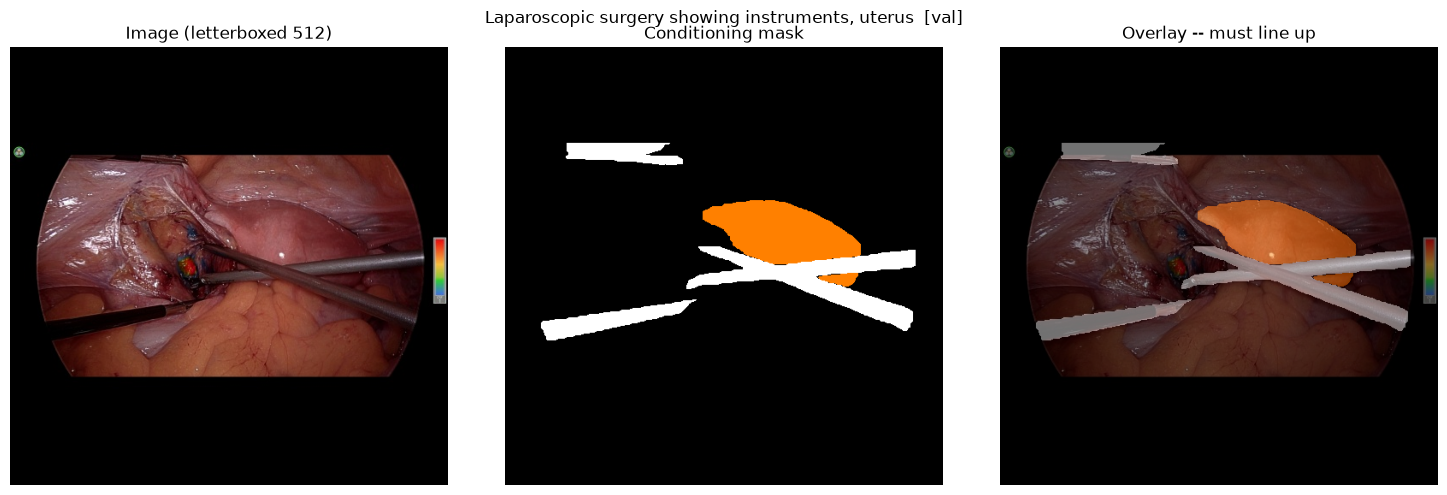

Check the overlay: masks must sit exactly on the structures.
Black bars top/bottom are the letterbox -- that is correct, not a bug.


In [10]:
# 10. Visual sanity check
sample = random.choice(records)
img  = cv2.cvtColor(cv2.imread(str(CONTROLNET_ROOT / sample["image"])), cv2.COLOR_BGR2RGB)
cond = cv2.cvtColor(cv2.imread(str(CONTROLNET_ROOT / sample["conditioning_image"])), cv2.COLOR_BGR2RGB)
assert img.shape == cond.shape == (SIZE, SIZE, 3), (img.shape, cond.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img);  ax[0].set_title("Image (letterboxed 512)")
ax[1].imshow(cond); ax[1].set_title("Conditioning mask")
ax[2].imshow(img);  ax[2].imshow(cond, alpha=0.45); ax[2].set_title("Overlay -- must line up")
for a in ax: a.axis("off")
plt.suptitle(f'{sample["text"]}  [{sample["split"]}]')
plt.tight_layout(); plt.show()

print("Check the overlay: masks must sit exactly on the structures.")
print("Black bars top/bottom are the letterbox -- that is correct, not a bug.")

In [11]:
# 11. Integrity check
bad = []
all_records = [json.loads(l) for l in open(CN_METADATA_PATH, encoding="utf-8")]
for rec in tqdm(all_records, desc="verifying"):
    ip, cp = CONTROLNET_ROOT / rec["image"], CONTROLNET_ROOT / rec["conditioning_image"]
    if not ip.exists() or not cp.exists():
        bad.append({"reason": "missing_file", **rec}); continue
    im, cm = cv2.imread(str(ip)), cv2.imread(str(cp))
    if im is None or cm is None:
        bad.append({"reason": "unreadable", **rec}); continue
    if im.shape != (SIZE, SIZE, 3) or cm.shape != (SIZE, SIZE, 3):
        bad.append({"reason": f"bad_shape {im.shape}/{cm.shape}", **rec})

print(f"Checked {len(all_records)} records, {len(bad)} problems.")
if bad:
    print(json.dumps(bad[:10], indent=2))
else:
    mb = sum(f.stat().st_size for f in CN_IMAGES_DIR.iterdir()) / 1e6
    mb += sum(f.stat().st_size for f in CN_COND_DIR.iterdir()) / 1e6
    print(f"All good. Dataset on disk: {mb:.0f} MB")
    print("Next: 03_train_controlnet.ipynb")

verifying:   0%|          | 0/9647 [00:00<?, ?it/s]

Checked 9647 records, 0 problems.
All good. Dataset on disk: 637 MB
Next: 03_train_controlnet.ipynb
